In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

In [3]:
# Load the data from the JSON file
characters = pd.read_json('characters.json')
devil_fruits = pd.read_json('devil_fruits.json')
islands = pd.read_json('islands.json')

In [4]:
# Keep columns of interest
characters = characters[['name', 'affiliation', 'first_appearance_arc', 'race', 'status', 'devil_fruit', 'origin', 'height', 'age', 'haki', 'bounty','relationships','journey']]
devil_fruits = devil_fruits[['name', 'english', 'type','user', 'description']]
islands = islands[['name', 'location', 'notable_members', 'current_ruler', 'notable_locations']]


In [5]:
#---Data Cleaning---

# --- BOUNTY CLEANING ---
characters['bounty'] = characters['bounty'].astype(str).str.replace(r'\D', '', regex=True)
characters['bounty'] = pd.to_numeric(characters['bounty'], errors='coerce').fillna(0)

# --- CHAPTER CLEANING ---
# Filter for manga-only characters
characters = characters[characters['first_appearance_arc'].str.contains('Chapter', na=False)].copy()

# Fix: Extract the number and convert to integer
characters['chapter_num'] = characters['first_appearance_arc'].str.extract(r'(\d+)').astype(int)

# Set display to avoid scientific notation in the console
pd.options.display.float_format = '{:.0f}'.format

In [6]:
# for each devil fruit user, find their type the chapter of their first appearance
fruits_useful = devil_fruits[['user', 'type']]
for i in range(len(fruits_useful)):
    user = fruits_useful.loc[i, 'user']
    fruit_type = fruits_useful.loc[i, 'type']
    chapter = characters[characters['name'] == user]['chapter_num'].values
    

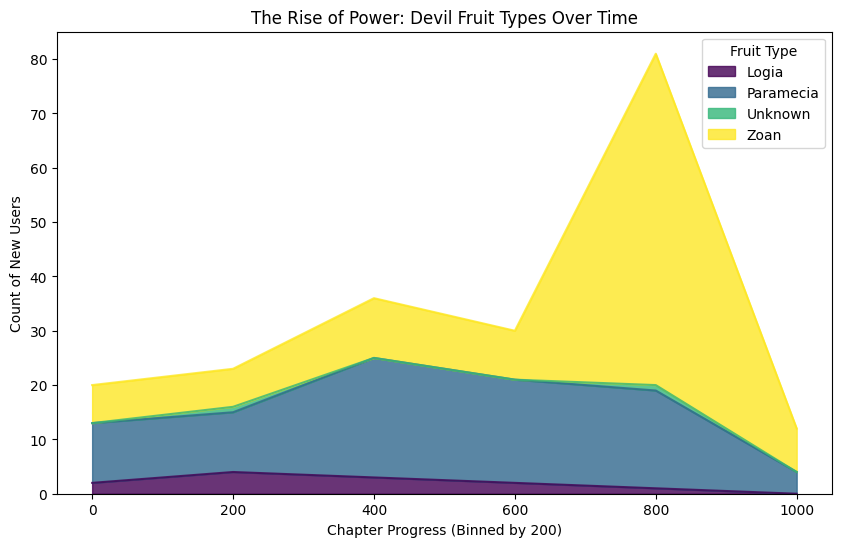

In [7]:
# This does exactly what your 'for' loop intends: 
# For each fruit user, find their type and their appearance chapter.
df_plot = devil_fruits[['user', 'type']].merge(
    characters[['name', 'chapter_num']], 
    left_on='user', 
    right_on='name'
)

# Now we prepare it for the Stacked Area Graph
# 1. Group by chapter intervals
df_plot['chapter_bin'] = (df_plot['chapter_num'] // 200) * 200

# 2. Create the pivot table (Cross-tabulation)
stacked_data = df_plot.groupby(['chapter_bin', 'type']).size().unstack(fill_value=0)

# 3. Plotting
ax = stacked_data.plot.area(figsize=(10, 6), alpha=0.8, colormap='viridis')

plt.title("The Rise of Power: Devil Fruit Types Over Time")
plt.xlabel("Chapter Progress (Binned by 200)")
plt.ylabel("Count of New Users")
plt.legend(title="Fruit Type")
plt.show()

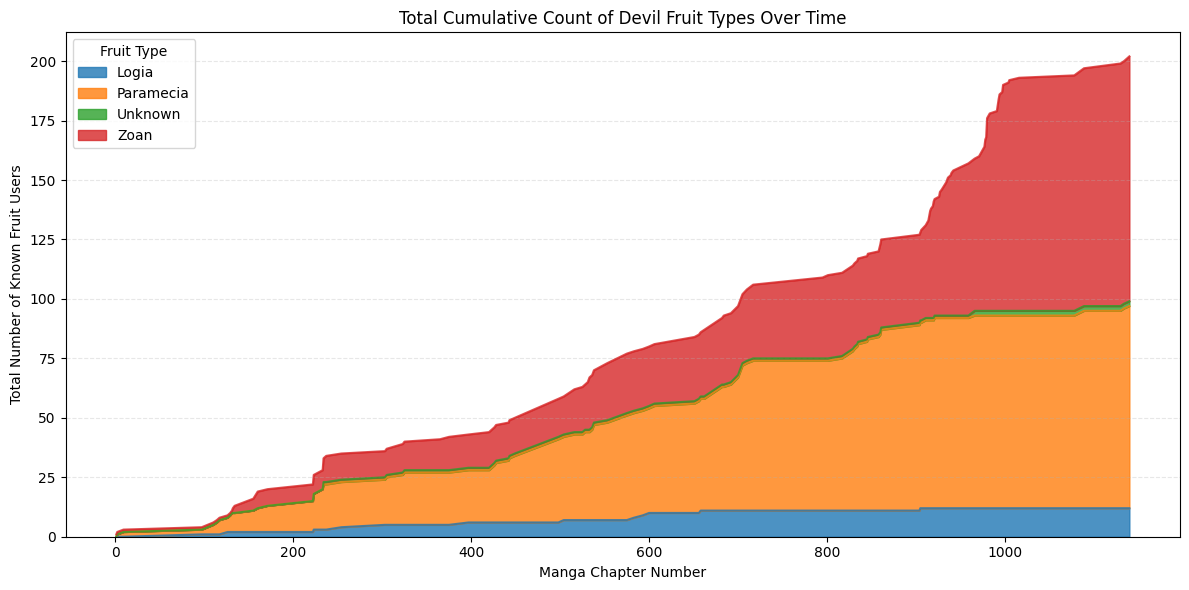

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare the data (Merging 'tables' like a database)
# We merge characters and devil_fruits to link the appearance chapter to the fruit type
df_cumulative = devil_fruits[['user', 'type']].merge(
    characters[['name', 'chapter_num']], 
    left_on='user', 
    right_on='name'
)

# 2. Sort by chapter to ensure the timeline is correct
df_cumulative = df_cumulative.sort_values('chapter_num')

# 3. Create a pivot table: Rows = Chapters, Columns = Fruit Types, Values = Count
# This creates a 'snapshot' of how many of each type appear in each chapter
counts_per_chapter = df_cumulative.groupby(['chapter_num', 'type']).size().unstack(fill_value=0)

# 4. CALCULATE CUMULATIVE SUM
# This adds the count of the current chapter to the total of all previous chapters
cumulative_data = counts_per_chapter.cumsum()

# 5. Plotting the Stacked Area Graph
ax = cumulative_data.plot.area(figsize=(12, 6), alpha=0.8)

# Requirements: Title, Axis Labels, Legend, and Annotation [cite: 2, 26, 27, 28]
plt.title("Total Cumulative Count of Devil Fruit Types Over Time")
plt.xlabel("Manga Chapter Number")
plt.ylabel("Total Number of Known Fruit Users")
plt.legend(title="Fruit Type", loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

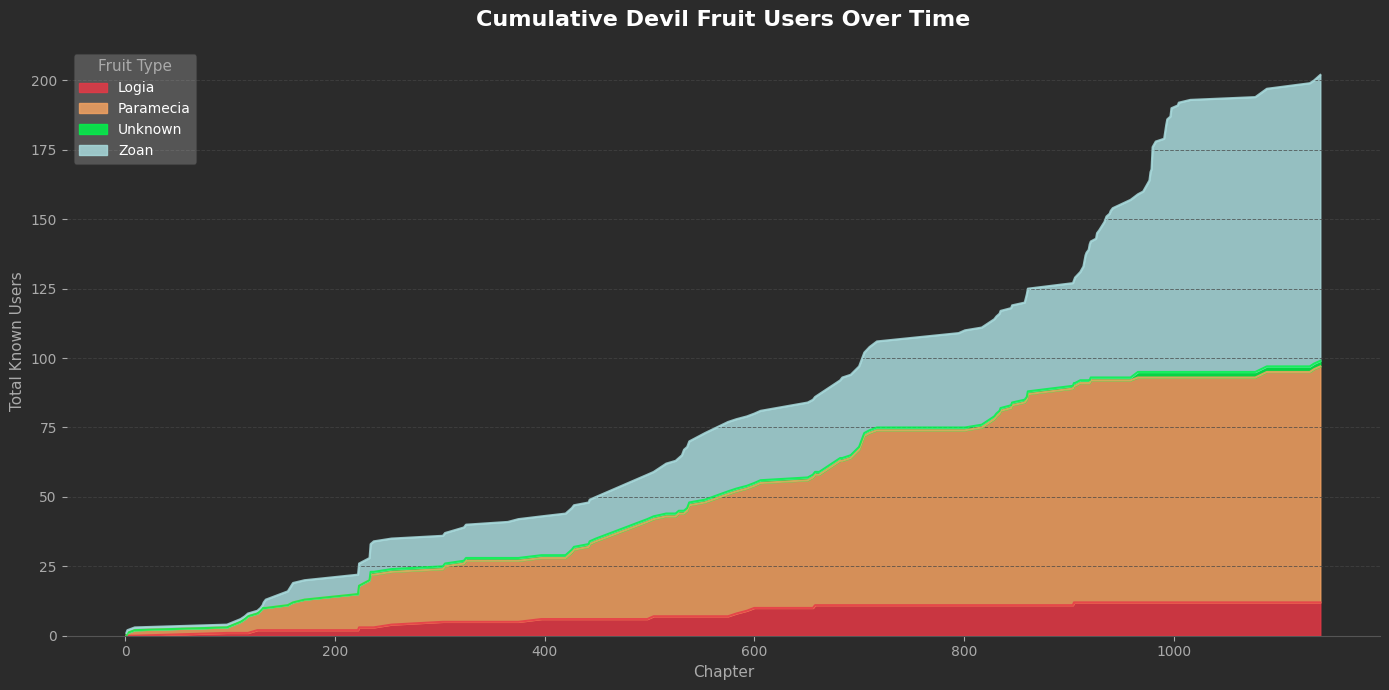

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 1. Prepare the data
df_cumulative = devil_fruits[['user', 'type']].merge(
    characters[['name', 'chapter_num']],
    left_on='user',
    right_on='name'
)

# 2. Sort by chapter
df_cumulative = df_cumulative.sort_values('chapter_num')

# 3. Pivot + cumulative sum
counts_per_chapter = df_cumulative.groupby(['chapter_num', 'type']).size().unstack(fill_value=0)
cumulative_data = counts_per_chapter.cumsum()

# 4. Plot
fig, ax = plt.subplots(figsize=(14, 7))

colors = ["#e63946", "#f4a261", "#01f34a", "#a8dadc"]  # one per fruit type — adjust if more types
cumulative_data.plot.area(ax=ax, alpha=0.85, color=colors[:len(cumulative_data.columns)])

# Styling
ax.set_facecolor("#2b2b2b")
fig.patch.set_facecolor("#2b2b2b")

ax.set_title("Cumulative Devil Fruit Users Over Time", fontsize=16, fontweight="bold", pad=15, color="white")
ax.set_xlabel("Chapter", fontsize=11, color="#aaa")
ax.set_ylabel("Total Known Users", fontsize=11, color="#aaa")
ax.tick_params(colors="#aaa")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#555")
ax.grid(axis="y", color="#444", linestyle="--", linewidth=0.7, alpha=0.7)

# Legend
legend = ax.legend(
    title="Fruit Type",
    loc="upper left",
    fontsize=10,
    title_fontsize=11,
    framealpha=0.2,
    labelcolor="white",
    edgecolor="#555"
)
legend.get_title().set_color("#aaa")

plt.tight_layout()
plt.show()

In [10]:
characters["affiliation"] = characters["affiliation"].replace(r".*Marines.*", "Marines", regex=True)
pirates = characters[characters["affiliation"]!="Marines"]
pirates.info()

<class 'pandas.DataFrame'>
Index: 1398 entries, 0 to 1531
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  1398 non-null   str    
 1   affiliation           1153 non-null   str    
 2   first_appearance_arc  1398 non-null   str    
 3   race                  1398 non-null   str    
 4   status                1398 non-null   str    
 5   devil_fruit           201 non-null    object 
 6   origin                546 non-null    str    
 7   height                391 non-null    float64
 8   age                   488 non-null    object 
 9   haki                  137 non-null    object 
 10  bounty                1398 non-null   float64
 11  relationships         1244 non-null   object 
 12  journey               1373 non-null   object 
 13  chapter_num           1398 non-null   int64  
dtypes: float64(2), int64(1), object(5), str(6)
memory usage: 235.2+ KB


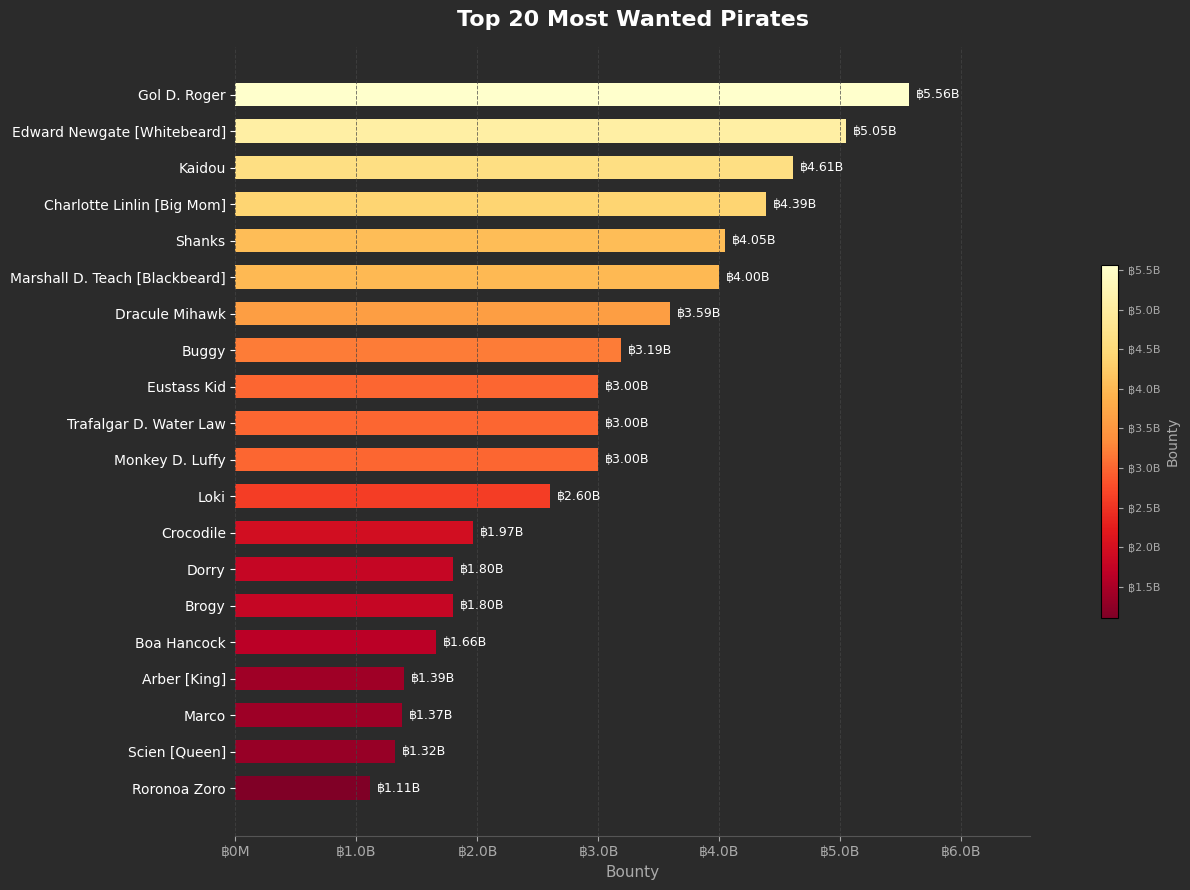

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

pirates_top20 = pirates.nlargest(20, "bounty").sort_values("bounty", ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))

cmap = plt.cm.YlOrRd_r  # reversed: yellow = highest bounty
norm = plt.Normalize(pirates_top20["bounty"].min(), pirates_top20["bounty"].max())
colors = [cmap(norm(b)) for b in pirates_top20["bounty"]]

bars = ax.barh(pirates_top20["name"], pirates_top20["bounty"], color=colors, height=0.65)

max_bounty = pirates_top20["bounty"].max()

# Value labels
for bar in bars:
    val = bar.get_width()
    label = f"฿{val/1e9:.2f}B" if val >= 1e9 else f"฿{val/1e6:.0f}M"
    ax.text(val + max_bounty * 0.01, bar.get_y() + bar.get_height() / 2,
            label, va="center", fontsize=9, color="white")

# Colorbar legend
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.02, pad=0.08)
cbar.set_label("Bounty", fontsize=10, color="#aaa")
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"฿{x/1e9:.1f}B" if x >= 1e9 else f"฿{x/1e6:.0f}M"
))
cbar.ax.tick_params(labelsize=8, colors="#aaa")

# Styling
ax.set_facecolor("#2b2b2b")
fig.patch.set_facecolor("#2b2b2b")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"฿{x/1e9:.1f}B" if x >= 1e9 else f"฿{x/1e6:.0f}M"
))
ax.set_xlabel("Bounty", fontsize=11, color="#aaa")
ax.set_title("Top 20 Most Wanted Pirates", fontsize=16, fontweight="bold", pad=15, color="white")
ax.tick_params(axis="y", labelsize=10, colors="white")
ax.tick_params(axis="x", colors="#aaa")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#555")
ax.grid(axis="x", color="#444", linestyle="--", linewidth=0.7, alpha=0.7)
ax.set_xlim(0, max_bounty * 1.18)

plt.tight_layout()
plt.show()

C:\Users\leost\AppData\Local\Temp\ipykernel_18148\2829004374.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


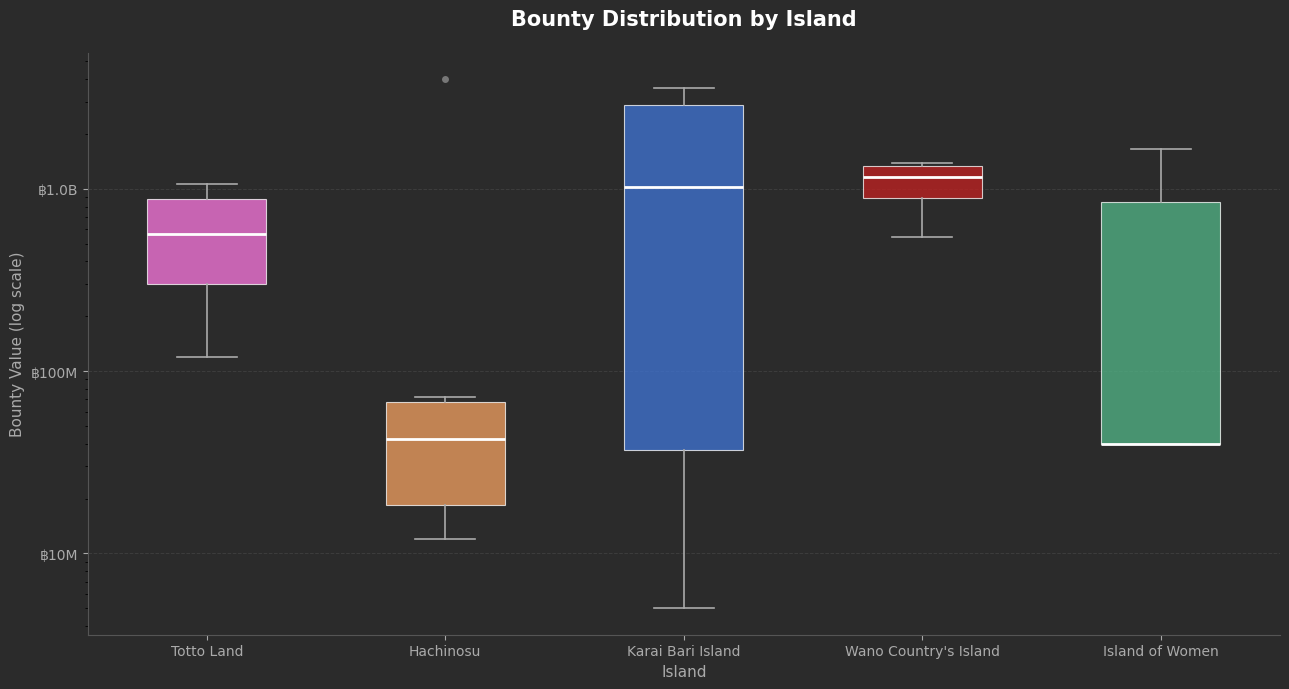

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# --- 1. Prepare and Filter Data ---

# Explode the islands so each notable member has their own row
islands_exploded = islands.explode("notable_members")

# Remove Marineford from the list
islands_exploded = islands_exploded[islands_exploded["name"] != "Marineford"]

# Merge with characters to get their bounties
merged = islands_exploded.merge(
    characters[["name", "bounty"]], 
    left_on="notable_members", 
    right_on="name", 
    how="inner"
)

# Filter for characters with actual bounties (removes 0 bounty members)
valid_bounties = merged[merged["bounty"] > 0].copy()

# --- 2. Find Top 5 Islands ---

# Count members with bounties per island
# This automatically skips islands that now have 0 members after our filters
island_counts = valid_bounties.groupby("name_x").size().sort_values(ascending=False)

# Get the names of the top 5 remaining islands
top5_names = island_counts.head(5).index.tolist()

# Filter our plotting data to only include these 5 islands
plot_df = valid_bounties[valid_bounties["name_x"].isin(top5_names)]

# --- 3. Plotting ---

fig, ax = plt.subplots(figsize=(13, 7))

# Prepare data for boxplot
data_per_island = [plot_df[plot_df["name_x"] == name]["bounty"].values for name in top5_names]

bp = ax.boxplot(
    data_per_island,
    labels=top5_names,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color="white", linewidth=2),
    whiskerprops=dict(color="#aaa", linewidth=1.2),
    capprops=dict(color="#aaa", linewidth=1.2),
    flierprops=dict(marker="o", markerfacecolor="#aaa", markersize=5,
                    markeredgecolor="none", alpha=0.6),
)

# Custom colors for the boxes
colors = ["#fc78e1", "#f4a261", "#4075D7", "#c32121", "#52b788"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
    patch.set_edgecolor("white")
    patch.set_linewidth(0.8)

# --- 4. Styling ---

ax.set_facecolor("#2b2b2b")
fig.patch.set_facecolor("#2b2b2b")

# Log Scale for visibility across vast bounty differences
ax.set_yscale("log")

# Formatting Y-axis to show Billions (B) and Millions (M)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"฿{x/1e9:.1f}B" if x >= 1e9 else f"฿{x/1e6:.0f}M" if x >= 1e6 else f"฿{x:,.0f}"
))

ax.set_title("Bounty Distribution by Island",
             fontsize=15, fontweight="bold", pad=20, color="white")
ax.set_xlabel("Island", fontsize=11, color="#aaa")
ax.set_ylabel("Bounty Value (log scale)", fontsize=11, color="#aaa")

ax.tick_params(colors="#aaa")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color("#555")
ax.grid(axis="y", color="#444", linestyle="--", linewidth=0.7, alpha=0.7)

plt.tight_layout()
plt.show()

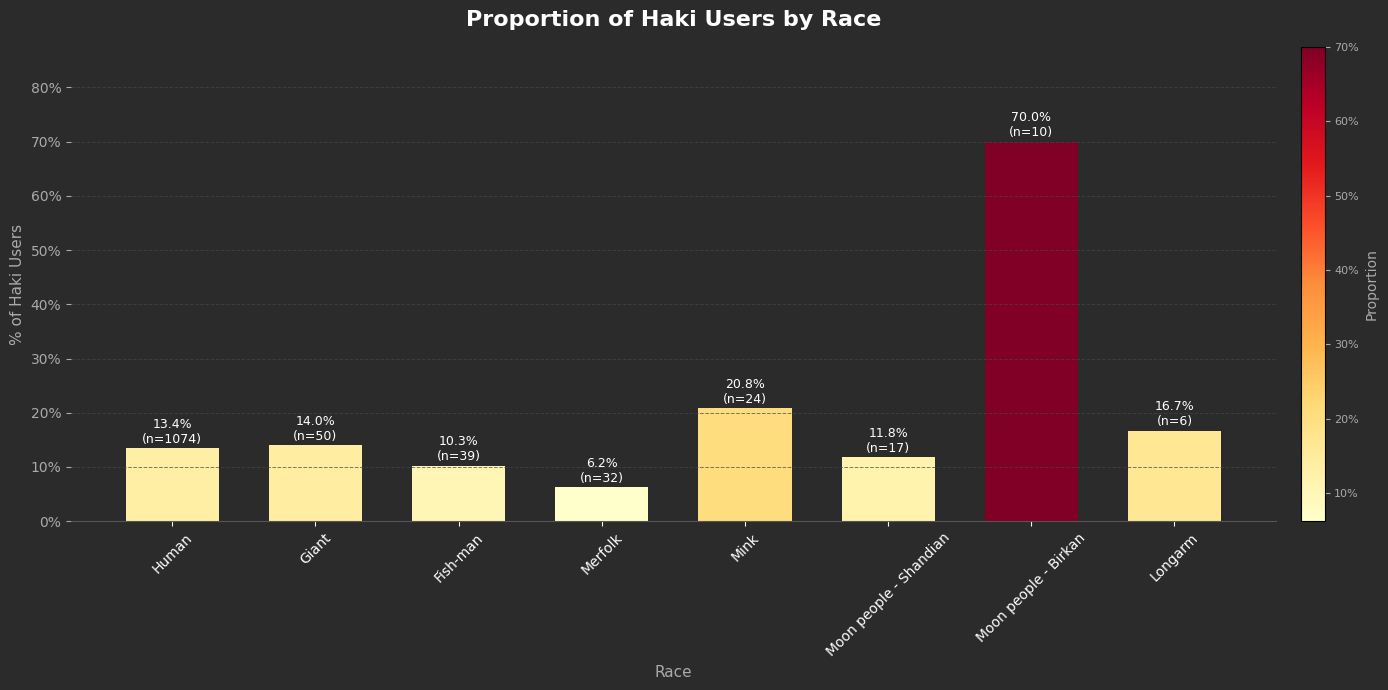

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

# Flag haki users (haki field is non-null)
characters["is_haki_user"] = characters["haki"].notna()

# Group by race: count total and haki users, compute proportion
race_haki = characters.groupby("race").agg(
    total=("name", "count"),
    haki_users=("is_haki_user", "sum")
).reset_index()

race_haki["proportion"] = race_haki["haki_users"] / race_haki["total"]

# Filter and sort alphabetically
race_haki = race_haki[(race_haki["total"] >= 5) & (race_haki["proportion"] > 0.05)].sort_values("total", ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))

# Gradient color based on proportion
cmap = plt.cm.YlOrRd
norm = plt.Normalize(race_haki["proportion"].min(), race_haki["proportion"].max())
colors = [cmap(norm(p)) for p in race_haki["proportion"]]

bars = ax.bar(race_haki["race"], race_haki["proportion"], color=colors, width=0.65)

# Value labels
for bar, (_, row) in zip(bars, race_haki.iterrows()):
    val = bar.get_height()
    label = f"{val*100:.1f}%\n(n={int(row['total'])})"
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
            label, ha="center", fontsize=9, color="white")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("Proportion", fontsize=10, color="#aaa")
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
cbar.ax.tick_params(labelsize=8, colors="#aaa")

# Styling
ax.set_facecolor("#2b2b2b")
fig.patch.set_facecolor("#2b2b2b")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax.set_title("Proportion of Haki Users by Race", fontsize=16, fontweight="bold", pad=15, color="white")
ax.set_ylabel("% of Haki Users", fontsize=11, color="#aaa")
ax.set_xlabel("Race", fontsize=11, color="#aaa")
ax.tick_params(axis="x", labelsize=10, colors="white", rotation=45)
ax.tick_params(axis="y", colors="#aaa")
ax.set_ylim(0, race_haki["proportion"].max() * 1.25)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#555")
ax.grid(axis="y", color="#444", linestyle="--", linewidth=0.7, alpha=0.7)

plt.tight_layout()
plt.show()